In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# %pip install mysql-connector-python
# %pip install tensorflow

In [2]:
import pandas as pd 
import numpy as np 
from sklearn.cluster import KMeans 
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split 
import matplotlib.pyplot as plt 
import tensorflow as tf 
# from tensorflow import keras 
 
np.random.seed(42) 
 
# ============================================================ 
# 1. GERAÇÃO DOS DADOS FICTÍCIOS (SQL + NoSQL integrados) 
# ============================================================ 
 
# Base relacional (tabelas SQL simuladas) 
clientes = pd.DataFrame({ 
    "id_cliente": np.arange(1, 101), 
    "nome": [f"Cliente_{i}" for i in range(1, 101)], 
    "idade": np.random.randint(18, 70, 100), 
    "renda": np.random.randint(1500, 15000, 100), 
    "categoria": np.random.choice(["Bronze", "Prata", "Ouro"], 100) 
 
}) 
 
vendas = pd.DataFrame({ 
    "id_venda": np.arange(1, 501), 
    "id_cliente": np.random.randint(1, 101, 500), 
    "valor": np.random.uniform(20, 800, 500).round(2), 
    "quantidade": np.random.randint(1, 12, 500), 
    "dia_semana": np.random.choice(["Seg", "Ter", "Qua", "Qui", "Sex", "Sab", 
"Dom"], 500) 
}) 
 
# Base NoSQL simulada (MongoDB) 
interacoes = pd.DataFrame({ 
    "id_cliente": np.random.randint(1, 101, 800), 
    "acao": np.random.choice(["clique", "busca", "favoritou", 
"adicionou_carrinho"], 800), 
    "produto": np.random.choice(["Arroz", "Feijão", "Café", "Açúcar", 
"Leite"], 800), 
    "timestamp": pd.date_range("2024-01-01", periods=800, freq="H") 
}) 
 
print("=== CLIENTES (SQL) ===") 
print(clientes.head()) 
 
print("\n=== VENDAS (SQL) ===") 
print(vendas.head()) 
 
print("\n=== INTERAÇÕES (MongoDB Simulado) ===") 
print(interacoes.head()) 

=== CLIENTES (SQL) ===
   id_cliente       nome  idade  renda categoria
0           1  Cliente_1     56  13576      Ouro
1           2  Cliente_2     69   1564    Bronze
2           3  Cliente_3     46   9506     Prata
3           4  Cliente_4     32   4068    Bronze
4           5  Cliente_5     60   6963    Bronze

=== VENDAS (SQL) ===
   id_venda  id_cliente   valor  quantidade dia_semana
0         1          99  436.79           8        Ter
1         2          89  604.93           3        Sab
2         3          99  732.27           2        Ter
3         4          25  476.42           3        Seg
4         5          93  586.37           5        Dom

=== INTERAÇÕES (MongoDB Simulado) ===
   id_cliente                acao produto           timestamp
0          99               busca  Feijão 2024-01-01 00:00:00
1          41           favoritou   Arroz 2024-01-01 01:00:00
2           6              clique   Leite 2024-01-01 02:00:00
3          25  adicionou_carrinho  Açúcar 20

/tmp/ipykernel_6046/2768087260.py:42: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "timestamp": pd.date_range("2024-01-01", periods=800, freq="H")


In [3]:
# ============================================================ 
# 2. CONSULTAS SQL SIMULADAS (via Pandas) 
# ============================================================ 
 
# SELECT + JOIN 
df = clientes.merge(vendas, on="id_cliente") 
 
# GROUP BY simulando SQL 
gastos = df.groupby("id_cliente")["valor"].sum().reset_index() 
gastos.rename(columns={"valor": "gasto_total"}, inplace=True) 
 
 
# ============================================================ 
# 3. FEATURE ENGINEERING (Data Mining) 
# ============================================================ 
 
df = df.merge(gastos, on="id_cliente") 
df["num_compras"] = df.groupby("id_cliente")["id_venda"].transform("count") 
df["ticket_medio"] = df["gasto_total"] / df["num_compras"] 

In [7]:
display(df)

,id_cliente,nome,idade,renda,categoria,id_venda,valor,quantidade,dia_semana,gasto_total,num_compras,ticket_medio
0,1,Cliente_1,56,13576,Ouro,173,374.33,10,Dom,2557.3,7,365.328571
1,1,Cliente_1,56,13576,Ouro,175,448.16,3,Dom,2557.3,7,365.328571
2,1,Cliente_1,56,13576,Ouro,180,22.11,5,Qua,2557.3,7,365.328571
3,1,Cliente_1,56,13576,Ouro,224,561.10,4,Qua,2557.3,7,365.328571
4,1,Cliente_1,56,13576,Ouro,394,162.04,3,Qui,2557.3,7,365.328571
...,...,...,...,...,...,...,...,...,...,...,...,...
495,100,Cliente_100,32,10401,Prata,210,721.74,6,Dom,2889.6,6,481.600000
496,100,Cliente_100,32,10401,Prata,216,325.36,10,Ter,2889.6,6,481.600000
497,100,Cliente_100,32,10401,Prata,308,628.79,6,Sab,2889.6,6,481.600000
498,100,Cliente_100,32,10401,Prata,327,314.63,8,Qui,2889.6,6,481.600000


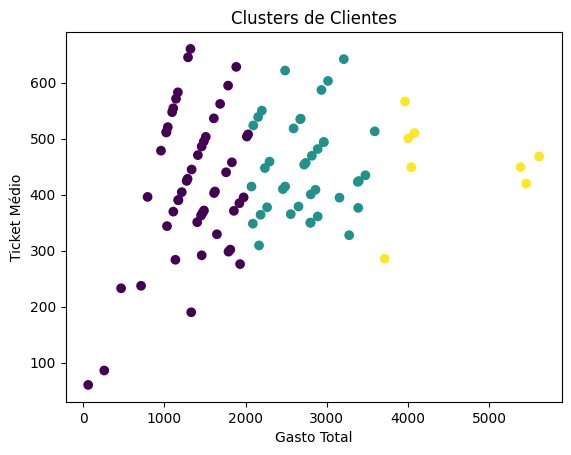

In [ ]:

# ============================================================ 
# 4. CLUSTERIZAÇÃO (Machine Learning) 
# ============================================================ 
 
cluster_data = df[["gasto_total", "num_compras", 
"ticket_medio"]].drop_duplicates() 


kmeans = KMeans(n_clusters=3, random_state=42) 
cluster_data["cluster"] = kmeans.fit_predict(cluster_data) 
 
# Plot 
plt.scatter(cluster_data["gasto_total"], cluster_data["ticket_medio"], 
c=cluster_data["cluster"]) 
plt.xlabel("Gasto Total") 
plt.ylabel("Ticket Médio") 
plt.title("Clusters de Clientes") 
plt.show() 

In [ ]:

# ============================================================ 
# 5. REGRESSÃO (Machine Learning) 
# Prevendo o gasto total baseado em idade e renda 
# ============================================================ 
 
X = clientes[["idade", "renda"]] 
y = gastos["gasto_total"] 
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) 
 
modelo_lr = LinearRegression() 
modelo_lr.fit(X_train, y_train) 
 
print("\nCoeficientes da Regressão:") 
print(modelo_lr.coef_) 
 
print("Intercepto:", modelo_lr.intercept_) 

In [ ]:

# ============================================================ 
# 6. MINI REDE NEURAL (Deep Learning) 
# Prevê gasto total futuro 
# ============================================================ 
 
modelo_nn = keras.Sequential([ 
    keras.layers.Dense(16, activation='relu', input_shape=(2,)), 
    keras.layers.Dense(8, activation='relu'), 
    keras.layers.Dense(1) 
]) 
 
modelo_nn.compile(optimizer='adam', loss='mse') 
 
historico = modelo_nn.fit(X_train, y_train, epochs=20, verbose=0) 
 
print("\nRede Neural treinada! Loss final:", historico.history["loss"][-1]) 
 
# ============================================================ 
# 7. MONGO SIMULADO + LGPD 
# ============================================================ 
 
# Geração de documento Mongo anonimizando nome 
documento_mongo = cluster_data.copy() 
documento_mongo["id_cliente_anon"] = ''
documento_mongo["id_cliente"].apply(lambda x: f"user_{x}") 
documento_mongo = documento_mongo.drop(columns=["id_cliente"]) 
documento_mongo.head().to_json("clientes_clusters_mongo.json", 
orient="records") 
 
print("\nDocumento MongoDB simulando envio com anonimização gerado!") 